In [5]:
import matplotlib.pyplot as plt
import numpy as np

models = [ "Depth- Projector", "ViVit", "3DCMA", "FlexiNet", "CNN + LSTM", "ConvLSTM", "Dinov2 + ConvLSTM", "DPFlow + EfficientNet (Ours)", "ConvLSTM w Attention", "Dinov2 + ConvLSTM w Spatial Reduction", "FastFlow + EfficientNet"]
rmse = [3.91,5.02,3.29,1.95,4.81,4.81,4.66,1.38,4.82,4.94, 0.74]
mae = [ 3.60, 4.23, 2.53, 1.06, 3.89, 4.23, 4.06, 1.09,4.17,4.33, 0.58]

# models = [ "Depth- Projector", "ViVit", "3DCMA", "FlexiNet", "CNN + LSTM", "ConvLSTM", "Dinov2 + ConvLSTM", "ConvLSTM w Attention", "Dinov2 + ConvLSTM w Spatial Reduction", "FastFlow + EfficientNet (Ours)"]
# rmse = [3.91,5.02,3.29,1.95,4.81,4.81,4.66,4.82,4.94, 0.74]
# mae = [ 3.60, 4.23, 2.53, 1.06, 3.89, 4.23, 4.06,4.17,4.33, 0.58]


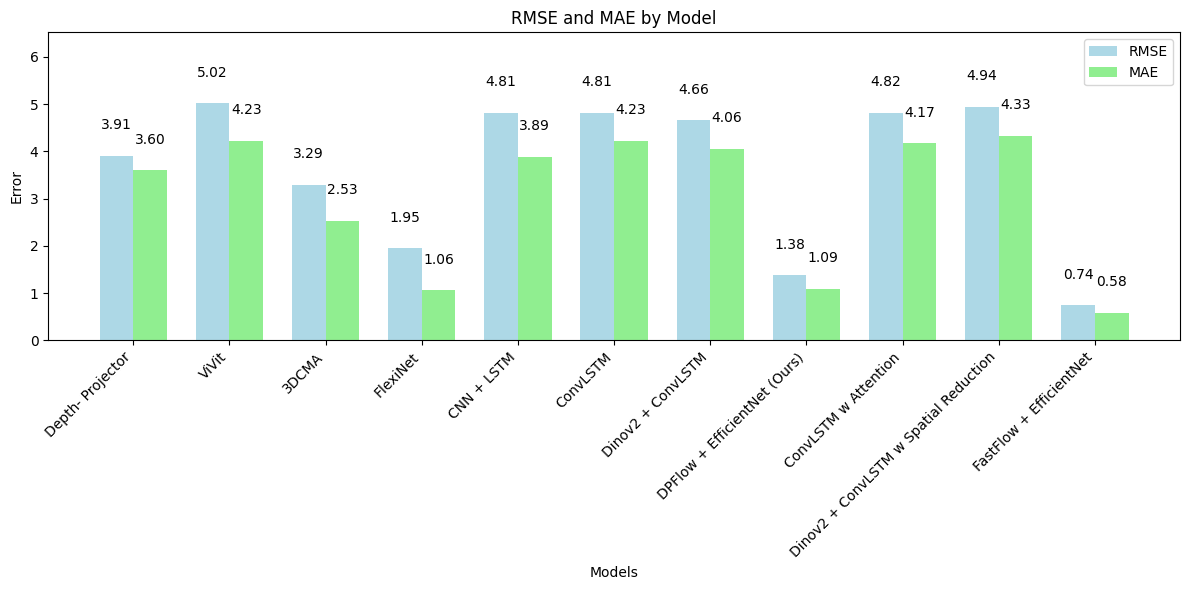

In [6]:
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, rmse, width, label='RMSE', color='lightblue')
bars2 = ax.bar(x + width/2, mae, width, label='MAE', color='lightgreen')

ax.set_title('RMSE and MAE by Model')
ax.set_xlabel('Models')
ax.set_ylabel('Error')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()

# Set y-axis limit to add more space at the top
ax.set_ylim(0, max(max(rmse), max(mae)) + 1.5)

# Add value labels on top of bars with more gap
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.2f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Percentage Improvement in Inference Time: 60.09%

FastFlowNet is 2.51x faster.



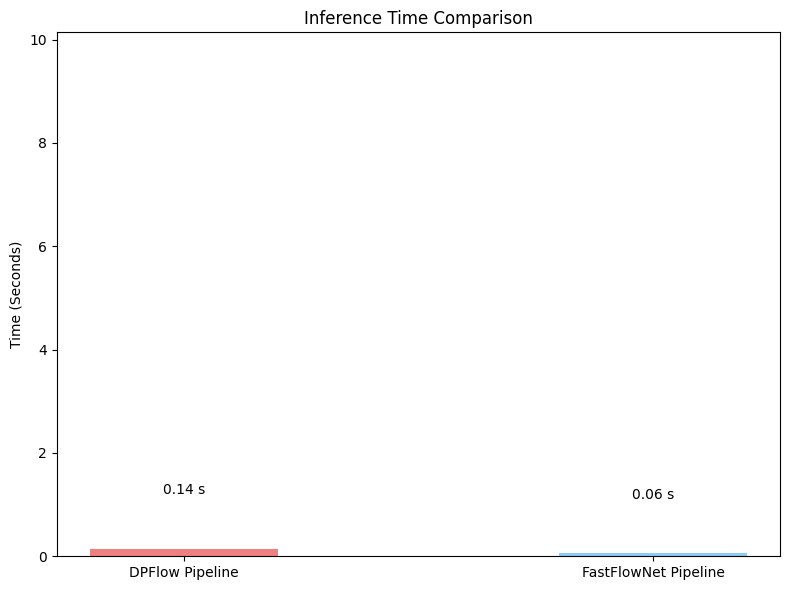

In [ ]:
import matplotlib.pyplot as plt

# Data
models_time = ['DPFlow Pipeline', 'FastFlowNet Pipeline']
inference_times = [66.17, 23.34]

# Calculate percentage improvement
# Formula: ((Old Time - New Time) / Old Time) * 100
improvement_percent = ((inference_times[0] - inference_times[1]) / inference_times[0]) * 100
print(f"Percentage Improvement in Inference Time: {improvement_percent:.2f}%\n")
print(f"FastFlowNet is {inference_times[0] / inference_times[1]:.2f}x faster.\n")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(models_time, inference_times, width=0.4, color=['lightcoral', 'lightskyblue'])

ax.set_title('Inference Time Comparison')
ax.set_ylabel('Time (Seconds)')
ax.set_ylim(0, max(inference_times) + 10) # Add some padding to the top

# Add text labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f} s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Run Inference on a Video

In [1]:
import cv2
from models import get_speeds_from_video_batch_process, get_speeds_from_video

def save_video_with_speeds(input_video_path, output_video_path, speeds, fps=None):
    """
    Reads an input video, overlays the calculated speed on the top-left corner
    of each frame, and saves the output as an MP4 file.
    """
    cap = cv2.VideoCapture(input_video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open input video {input_video_path}")
        return

    # If fps is not provided, use the original video's fps
    if fps is None:
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps == 0 or fps != fps: # fallback for invalid fps reading
            fps = 30.0
            
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Use mp4v codec for standard .mp4 files
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
    
    frame_idx = 0
    total_speed_frames = len(speeds)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Get speed for the current frame, default to last known speed if we run out
        if frame_idx < total_speed_frames:
            speed = speeds[frame_idx]
        else:
            speed = speeds[-1] if total_speed_frames > 0 else 0.0
        
        # Put text in the top-left corner
        text = f"Speed: {speed:.2f} m/s"
        
        # Draw background rectangle for better text visibility (optional)
        text_size, _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)
        cv2.rectangle(frame, (20, 20), (40 + text_size[0], 40 + text_size[1]), (0, 0, 0), -1)
        
        # Write text in top left corner
        cv2.putText(frame, text, (30, 40 + text_size[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2, cv2.LINE_AA)
        
        out.write(frame)
        frame_idx += 1
        
    cap.release()
    out.release()
    print(f"Video saved successfully to {output_video_path}")


# --- EXECUTION BLOCK ---

# Path settings
video_path = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_Cleaned\Dataset\Processed\Train\videos\2011_09_26_drive_0029_sync.mp4"
weights_path = r"D:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\Speed_Estimation_FYP_Cleaned\Speed_Estimation_Module_Lucentra\weights"

# Model settings
model_name = 'dpflow'  # Choose from: 'fastflownet', 'dpflow'

# Smoothing parameters
alpha = 0.5 # 0.3 - 0.5 works well
threshold = 2.0
sigma = 4.5  # 4-5 gives good smoothing
smoothing_type = "ema_gaussian"  # Choose from: "ema_threshold", "ema_gaussian", "ema", "gaussian"

# Get speeds from the video batch process
speeds = get_speeds_from_video_batch_process(
    video_path, 
    weights_path, 
    model_name=model_name, 
    alpha=alpha, 
    threshold=threshold, 
    sigma=sigma, 
    smoothing_type=smoothing_type, 
    use_smoothing=True
)

# Save the final video (this will happen exactly once now)
save_video_with_speeds(video_path, f'{model_name}_output_speed.mp4', speeds)
print("Finished completely.")

d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\D-Documents\Self-Improvement\Python\Computer_Vision\Speed Estimation\venv\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[!!alt_cuda_corr is not compiled!!]


2026-04-16 15:18:33.257 | INFO     | ptlflow.models.dpflow.dpflow:__init__:158 - DPFlow: --model.pyramid_levels is not set, the number of pyramid levels will be inferred from the input size.
2026-04-16 15:18:33.521 | INFO     | ptlflow:restore_model:283 - Restored model state from checkpoint: kitti
2026-04-16 15:18:34.151 | INFO     | ptlflow.models.dpflow.dpflow:forward_flow:366 - DPFlow: Detected change in input size. The number of pyramid levels will change to 3, corresponding to output stride 32.


Error: Unable to read video.
Using DPFlow model for optical flow estimation (Batch).
Video saved successfully to dpflow_output_speed.mp4
Finished completely.
